<a href="https://colab.research.google.com/github/faridsimba87-cpu/CDAV/blob/main/Lesson_6_Geopandas_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Lesson 6 — GeoPandas**

**GeoPandas = pandas + maps.** It's just a pandas DataFrame with one special column, `geometry`, that holds shapes (points, lines, polygons). Everything you know about pandas still works, plus you can plot maps and do spatial calculations.

In this lesson we use a **map of Kenya's 47 counties** to learn:

- What a GeoDataFrame is
- Loading map data (and what a **shapefile** is)
- Drawing maps and **choropleths** (colour-by-value maps)
- **Coordinate systems** (CRS)
- Spatial operations: which county is a city in? how far apart are two towns?
- Interactive maps

**Documentation:** https://geopandas.org/en/stable/docs.html

In [1]:
# Install the packages
!pip install geopandas folium mapclassify

In [2]:
#import libraries
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

---
### **GeoDataFrame**
Build a GeoDataframe from a few Kenyan cities.

Use the [https://www.randomcoords.com/region/kenya ] to select counties of your choice.

Each city is a `Point(longitude, latitude)`.

**geometry** — the shape in each row (here, a Point).

**CRS** (Coordinate Reference System) — what the numbers *mean*. `EPSG:4326` is plain longitude/latitude in **degrees**.

In [3]:
# Create a GeoDataFrame Dataset
cities = gpd.GeoDataFrame(
    {"city": ["Nairobi", "Mombasa", "Kisumu", "Nakuru", "Eldoret"]},
    geometry=[Point(36.8172, -1.2864),
              Point(39.6682, -4.0435),
              Point(34.7617, -0.0917),
              Point(36.0800, -0.3031),
              Point(35.2699,  0.5143)],
    crs="EPSG:4326")  # 4326 = ordinary latitude/longitude
cities

,city,geometry
0,Nairobi,POINT (36.8172 -1.2864)
1,Mombasa,POINT (39.6682 -4.0435)
2,Kisumu,POINT (34.7617 -0.0917)
3,Nakuru,POINT (36.08 -0.3031)
4,Eldoret,POINT (35.2699 0.5143)


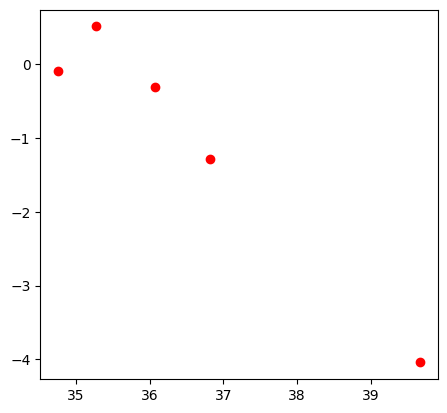

In [4]:
#simple plot
cities.plot(color="red")
plt.show()

---
### **Loading map data**
### What is a shapefile?
A **shapefile** isn't one file — it's a set that must stay together:

| File | Holds |
|---|---|
| `.shp` | the geometry (shapes) |
| `.shx` | an index |
| `.dbf` | the attribute table (like a spreadsheet) |
| `.prj` | the coordinate system |

GeoPandas reads shapefiles, GeoJSON, and more with the **same** function: `gpd.read_file()`.


In [5]:
# Load Kenya's counties from an online GeoJSON (It works exactly like reading a `.shp`).
url = "https://raw.githubusercontent.com/mikelmaron/kenya-election-data/master/data/counties.geojson"
counties = gpd.read_file(url)
print(counties.shape)     # (rows, columns)
counties.head()

(48, 9)


,OBJECTID,ID_,COUNTY_NAM,CONST_CODE,CONSTITUEN,COUNTY_COD,Shape_Leng,Shape_Area,geometry
0,1,5543,NAIROBI,288,KAMUKUNJI,47,1.559787,0.057423,"POLYGON ((36.90458 -1.16071, 36.90809 -1.16157..."
1,2,6634,MOMBASA,3,KISAUNI,1,0.885586,0.023325,"POLYGON ((39.68311 -4.06074, 39.68091 -4.06233..."
2,3,6600,KWALE,10,KINANGO,2,4.284182,0.758266,"POLYGON ((39.32093 -3.57045, 39.31934 -3.57515..."
3,4,6731,KILIFI,13,KALOLENI,3,5.333080,1.025338,"POLYGON ((39.71113 -3.91115, 39.70691 -3.91157..."
4,5,5806,TANA RIVER,19,GALOLE,4,10.280449,3.184213,"POLYGON ((39.02814 -0.00398, 39.03632 -0.00416..."


In [6]:
# Data Cleaning: Rename column, make names title case and only have county and geometry as the columns
counties = (counties.dropna(subset=["COUNTY_NAM"])
                    .rename(columns={"COUNTY_NAM": "county"}))
counties["county"] = counties["county"].str.title()
counties = counties[["county", "geometry"]].reset_index(drop=True)
print("Counties:", len(counties))
counties.head()

Counties: 47


,county,geometry
0,Nairobi,"POLYGON ((36.90458 -1.16071, 36.90809 -1.16157..."
1,Mombasa,"POLYGON ((39.68311 -4.06074, 39.68091 -4.06233..."
2,Kwale,"POLYGON ((39.32093 -3.57045, 39.31934 -3.57515..."
3,Kilifi,"POLYGON ((39.71113 -3.91115, 39.70691 -3.91157..."
4,Tana River,"POLYGON ((39.02814 -0.00398, 39.03632 -0.00416..."


> **Note:** Shapefiles often arrive **zipped**. You can read one without unzipping: `gpd.read_file("kenya_counties.zip")`.

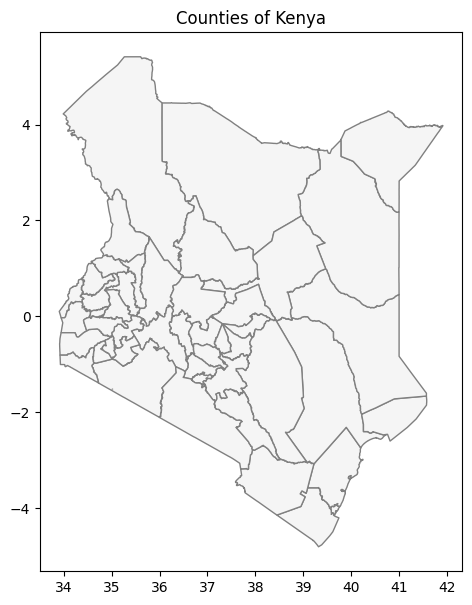

In [7]:
# Drawing the Map
counties.plot(figsize=(7, 7), color="whitesmoke", edgecolor="grey") #the edgecolor shows the county borders
plt.title("Counties of Kenya")
plt.show()

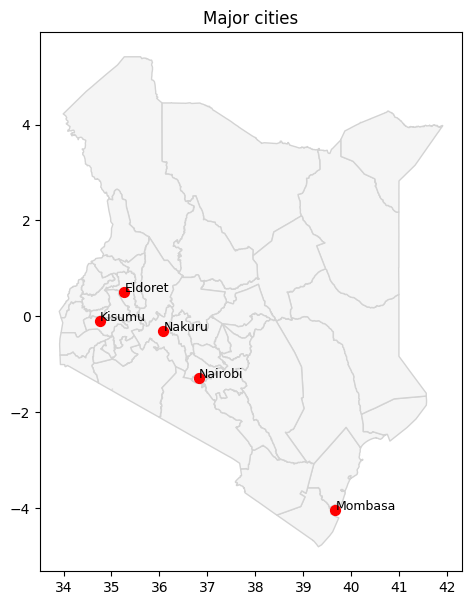

In [8]:
# Put the cities on the map (this is from the df earlier created)
ax = counties.plot(figsize=(7, 7), color="whitesmoke", edgecolor="lightgrey")
cities.plot(ax=ax, color="red", markersize=50)
for _, r in cities.iterrows():                     # label each city
    ax.annotate(r["city"], (r.geometry.x, r.geometry.y), fontsize=9)
ax.set_title("Major cities")
plt.show()

---
### **Coordinate systems: measuring area**
Degrees can't measure area in km². Reproject to a **metric** CRS for Kenya (`EPSG:32737`, UTM zone 37S), compute area, then keep it as a column.

In [9]:
counties_m = counties.to_crs(epsg=32737)           # new variable for to measure the area
counties["area_km2"] = (counties_m.area / 1_000_000).round(0) #add new colum to existing df
counties.sort_values("area_km2", ascending=False).head()

,county,geometry,area_km2
10,Marsabit,"POLYGON ((36.25593 4.45183, 36.26471 4.44823, ...",76028.0
22,Turkana,"POLYGON ((35.63233 5.37267, 35.63593 5.37187, ...",70352.0
8,Wajir,"POLYGON ((39.78589 3.69286, 39.78589 3.61284, ...",56645.0
7,Garissa,"POLYGON ((39.61219 0.68662, 39.6139 0.68303, 3...",43579.0
4,Tana River,"POLYGON ((39.02814 -0.00398, 39.03632 -0.00416...",39150.0


### Choropleth — colour counties by a value
Pass `column=` to shade each county by its area. Bigger = darker.

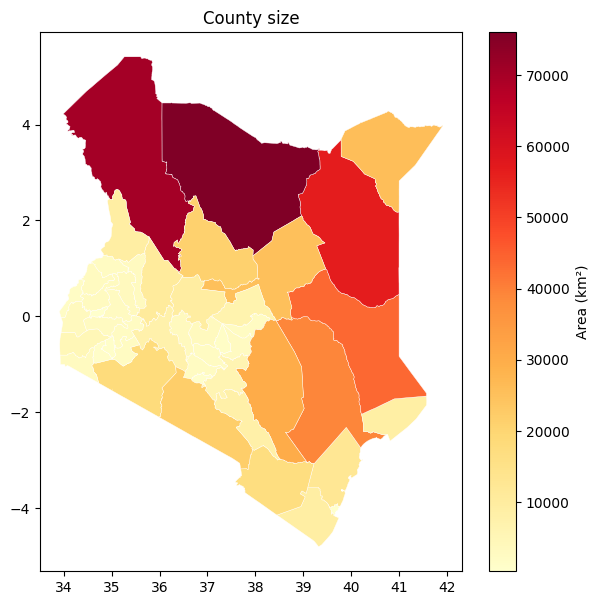

In [10]:
#colour counties by a value (Chloropleth)
counties.plot(column="area_km2", cmap="YlOrRd", legend=True,
              figsize=(7, 7), edgecolor="white", linewidth=0.3,
              legend_kwds={"label": "Area (km²)"})
plt.title("County size")
plt.show()

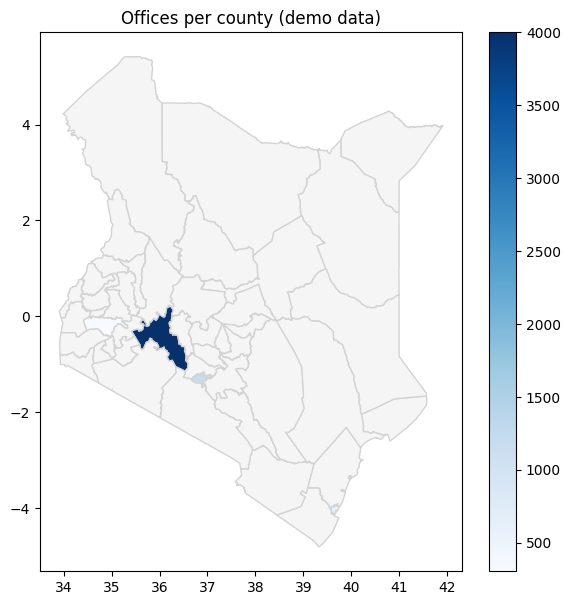

In [ ]:
# Add your own sample data and plot
import pandas as pd
my_data = pd.DataFrame({"county": ["Nairobi", "Mombasa", "Kisumu", "Nakuru"],
                        "offices": [1200, 665, 305, 4000]})
counties2 = counties.merge(my_data, on="county", how="left")   # keep all counties
counties2.plot(column="offices", cmap="Blues", legend=True,
               figsize=(7, 7), edgecolor="lightgrey",
               missing_kwds={"color": "whitesmoke"})
plt.title("Offices per county (demo data)")
plt.show()

/tmp/ipykernel_3664/2307710222.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centres = counties.geometry.centroid


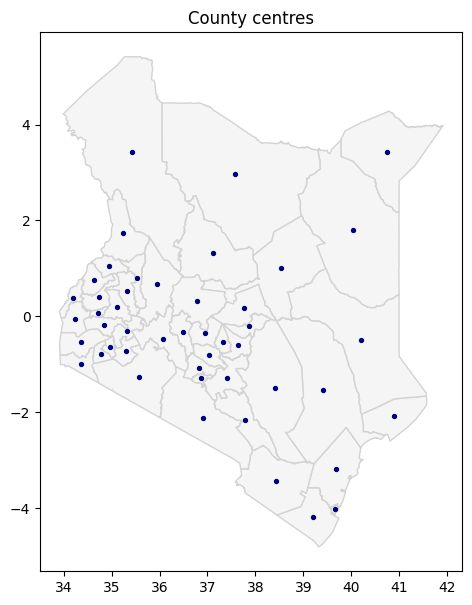

In [ ]:
# Spatial Operations: Use county centres as centroids
centres = counties.geometry.centroid
ax = counties.plot(figsize=(7, 7), color="whitesmoke", edgecolor="lightgrey")
centres.plot(ax=ax, color="navy", markersize=8)
ax.set_title("County centres")
plt.show()

In [ ]:
# Spatial Join: Matching a city point to county: `sjoin`
located = gpd.sjoin(cities, counties, predicate="within")
located[["city", "county"]]

,city,county
0,Nairobi,Nairobi
1,Mombasa,Mombasa
2,Kisumu,Kisumu
3,Nakuru,Nakuru
4,Eldoret,Uasin Gishu


In [ ]:
# Measure distance between cities
cities_m = cities.to_crs(epsg=32737)
nairobi, mombasa = cities_m.geometry.iloc[0], cities_m.geometry.iloc[1]
print(f"Nairobi to Mombasa: {nairobi.distance(mombasa) / 1000:.0f} km")

Nairobi to Mombasa: 440 km


---
### **Interactive maps**

**Folium markers:** A slippy map you can pan and zoom.

In [ ]:
import folium
m = folium.Map(location=[-0.5, 37.5], zoom_start=6)   # centre on Kenya
for _, r in cities.iterrows():
    folium.Marker([r.geometry.y, r.geometry.x], popup=r["city"]).add_to(m)
m

In [ ]:
#.explore() - easy interactive chloropleth (uses folium + mapclassify)
counties.explore(column="area_km2", cmap="YlOrRd", legend=True)

---
### **Save your work**

GeoJSON is a single, easy-to-share file.

In [ ]:
counties.to_file("kenya_counties.geojson", driver="GeoJSON")
print("Saved.")

Saved.


In [ ]:
# To open a geopandas file
kenya_gdf = gpd.read_file("kenya_counties.geojson")
kenya_gdf

,county,area_km2,geometry
0,Nairobi,707.0,"POLYGON ((36.90458 -1.16071, 36.90809 -1.16157..."
1,Mombasa,286.0,"POLYGON ((39.68311 -4.06074, 39.68091 -4.06233..."
2,Kwale,9302.0,"POLYGON ((39.32093 -3.57045, 39.31934 -3.57515..."
3,Kilifi,12594.0,"POLYGON ((39.71113 -3.91115, 39.70691 -3.91157..."
4,Tana River,39150.0,"POLYGON ((39.02814 -0.00398, 39.03632 -0.00416..."
5,Lamu,9152.0,"POLYGON ((41.07789 -2.38246, 40.85975 -2.55543..."
6,Taita Taveta,17116.0,"POLYGON ((38.17389 -2.69984, 38.18213 -2.70393..."
7,Garissa,43579.0,"POLYGON ((39.61219 0.68662, 39.6139 0.68303, 3..."
8,Wajir,56645.0,"POLYGON ((39.78589 3.69286, 39.78589 3.61284, ..."
9,Mandera,25984.0,"MULTIPOLYGON (((41.73334 3.98662, 41.73133 3.9..."


---
### **Exercises**

Create a dataframe of the human population for each county and plot the static map and also plot an interactive map showing the population in each county.